# RE2.3 · Informe comparativo: tablas y figuras

Sobre los volcados de `runs/*/` y el reporte de `compare_models.py` (IoU ≥ 0.3, 100 cajas por
ventana, umbral elegido en val, medido en test): resumen por modelo, curvas, los tres ejes
(detección, encuadre, clasificación), desglose por clase y las mismas ventanas de test con las
detecciones de todos los modelos. Todo va a `figures/RE_2-3/` para `RE_2-3_informe-comparativo.tex`.

In [1]:
import json
from collections.abc import Sequence
from pathlib import Path
from typing import NamedTuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import reporte
import torch
from matplotlib.axes import Axes
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.transforms import ScaledTranslation
from reporte import TEXT_WIDTH_IN, number, percent
from torch import Tensor
from torchvision.ops import box_convert, box_iou

from core.config import RUNS_DIR, SEED, P
from data import cache
from data.species import LabelSet, split_label
from evaluation.evaluator import ModelDumps, load_dumps, path_for
from evaluation.metrics import (
    MATCH_IOU,
    Boxes,
    PerClassAP,
    assignments,
    average_precision,
    average_precision_per_class,
    detection_classes,
    hits,
    mean_average_precision,
    overlaps,
    rows_by_image,
    window_classes,
)
from evaluation.protocol import (
    MIN_PRECISIONS,
    THRESHOLD_GRID,
    Matched,
    equalize,
    match,
    operating_point,
    select,
)
from utils.audio import mel_to_unit

OUT = reporte.out_dir("RE_2-3")
RUNS = {
    "yolo26s_v2": "YOLO26s",
    "frcnn_v2": "Faster R-CNN",
    "detr_t10_logmel_v2": "AST-DETR log-mel",
    "detr_t10_logmel_birds": "AST-DETR aves",
    "detr_resnet": "ResNet-50 DETR",
    "detr_t10_pcen_v2": "AST-DETR PCEN",
}
COLORS = dict(
    zip(RUNS, ["#00b4d8", "#1e40af", "#22c55e", "#7c3aed", "#ff5fa2", "#f59e0b"], strict=True)
)
# La comparación guardada antes de añadir la supresión de no máximos a los DETR (RE2.1).
WITHOUT_NMS = RUNS_DIR / "comparacion" / "comparacion_modelos_detr_sin_nms.json"
MARKERS = dict(zip(MIN_PRECISIONS, ("o", "s"), strict=True))
IOU_LEVELS = (0.25, 0.3, 0.5)
N_SHOWN, COLUMNS = 4, 2
ANNOTATION_COLOR = "white"
CAPTION_BOX = {"facecolor": "black", "alpha": 0.55, "pad": 1.0, "lw": 0}
MARK_STEP_PT = 9
WINDOWS_PER_HOUR = 3600 / P.clip_hop_s  # una hora de audio en ventanas de 3 s con salto de 1,5 s

In [2]:
class Evaluated(NamedTuple):
    dumps: ModelDumps
    test: Boxes  # predicciones de test igualadas, en orden de score
    matched: Matched
    thresholds: dict[float, float]  # precisión mínima en val -> umbral
    ap: PerClassAP


def evaluate(dumps: ModelDumps) -> Evaluated:
    matched_val = match(equalize(dumps.val.predictions), dumps.val.truth, dumps.val.n_images)
    thresholds = {
        p: chosen.threshold
        for p in MIN_PRECISIONS
        if (chosen := select(matched_val, p)) is not None
    }
    test = equalize(dumps.test.predictions)
    return Evaluated(
        dumps,
        test,
        match(test, dumps.test.truth, dumps.test.n_images),
        thresholds,
        average_precision_per_class(test, dumps.test.truth, len(dumps.test.labels)),
    )


paths = [path_for(RUNS_DIR / run, run, split) for run in RUNS for split in (cache.VAL, cache.TEST)]
models = {dumps.model: evaluate(dumps) for dumps in load_dumps(paths)}
reference = models[next(iter(RUNS))].dumps.test
labels = LabelSet(reference.labels)
truth = reference.truth
detection = detection_classes(truth, len(labels))
saturated = window_classes(truth, len(labels))
report = json.loads((RUNS_DIR / "comparacion" / "comparacion_modelos.json").read_text())
by_model = {m["model"]: m for m in report["models"]}
print(
    f"test: {reference.n_images} ventanas · {len(truth.boxes)} cajas · {len(detection)} clases de detección"
)

test: 7599 ventanas · 7924 cajas · 23 clases de detección


In [3]:
# Resumen: mAP@0.3 y los dos puntos pareados con su IC de grabaciones (del reporte).
def paired(run: str, position: int) -> dict:
    return by_model[run]["paired"][position]


rows = []
for run, name in RUNS.items():
    first, second = paired(run, 0), paired(run, 1)
    tp, above = first["test"]["n_tp"], first["test"]["n_above"]
    f1 = 2 * tp / (above + len(truth.boxes))
    rows.append(
        (
            name,
            number(by_model[run]["map_30"], 3),
            number(first["threshold"], 2),
            f"{number(first['test']['recall'], 3)} [{number(first['interval']['recall'][0], 3)}, {number(first['interval']['recall'][1], 3)}]",
            f"{number(first['test']['precision'], 3)} [{number(first['interval']['precision'][0], 3)}, {number(first['interval']['precision'][1], 3)}]",
            number(f1, 3),
            number(second["threshold"], 2),
            number(second["test"]["recall"], 3),
            number(second["test"]["precision"], 3),
        )
    )
reporte.write_rows(OUT / "resumen.tex", rows)
pd.DataFrame(
    rows,
    columns=[
        "modelo",
        "mAP@0.3",
        "umbral",
        "recall",
        "precisión",
        "F1",
        "umbral 0.5",
        "recall",
        "precisión",
    ],
)

,modelo,mAP@0.3,umbral,recall,precisión,F1,umbral 0.5,recall,precisión
0,YOLO26s,"0,632","0,10","0,812 [0,792, 0,833]","0,696 [0,673, 0,719]","0,750","0,01","0,879","0,528"
1,Faster R-CNN,"0,595","0,74","0,757 [0,731, 0,782]","0,700 [0,680, 0,720]","0,727","0,34","0,857","0,505"
2,AST-DETR log-mel,"0,608","0,27","0,799 [0,778, 0,822]","0,709 [0,687, 0,730]","0,752","0,12","0,884","0,501"
3,AST-DETR aves,"0,609","0,26","0,814 [0,791, 0,838]","0,707 [0,687, 0,726]","0,757","0,11","0,884","0,497"
4,ResNet-50 DETR,"0,602","0,33","0,785 [0,763, 0,808]","0,708 [0,686, 0,729]","0,745","0,17","0,897","0,491"
5,AST-DETR PCEN,"0,560","0,28","0,766 [0,742, 0,790]","0,693 [0,671, 0,714]","0,728","0,13","0,853","0,497"


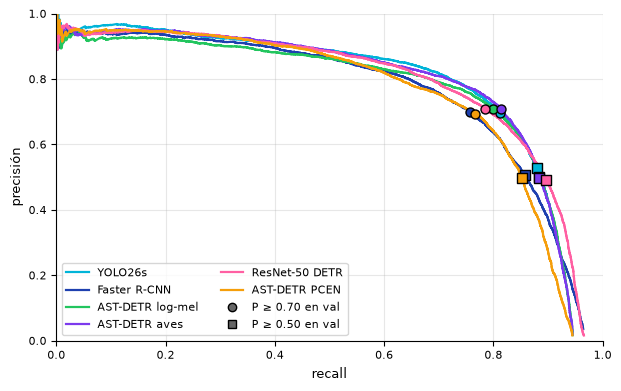

In [4]:
def pr_curve(matched: Matched) -> tuple[Tensor, Tensor]:
    true_positives = matched.found.cumsum(0)
    return true_positives / matched.n_gt, true_positives / torch.arange(1, len(true_positives) + 1)


fig, pr = plt.subplots(figsize=(TEXT_WIDTH_IN, 3.8), constrained_layout=True)
for run, m in models.items():
    recall, precision = pr_curve(m.matched)
    pr.plot(recall, precision, color=COLORS[run], lw=1.6, label=RUNS[run])
    for min_precision, threshold in m.thresholds.items():
        point = operating_point(m.matched, threshold)
        pr.scatter(
            point.recall or 0.0,
            point.precision or 0.0,
            marker=MARKERS[min_precision],
            color=COLORS[run],
            edgecolor="black",
            s=42,
            zorder=3,
        )
pr.set(xlabel="recall", ylabel="precisión", xlim=(0, 1), ylim=(0, 1))
handles = [
    *pr.get_legend_handles_labels()[0],
    *(
        Line2D(
            [], [], ls="", marker=MARKERS[p], color="#666", mec="black", label=f"P ≥ {p:.2f} en val"
        )
        for p in MIN_PRECISIONS
    ),
]
pr.legend(handles=handles, loc="lower left", ncol=2)
reporte.save_figure(fig, OUT / "curvas_pr")
plt.show()

In [5]:
# Los tres ejes. Detección: recall/precisión sin clase. Encuadre: IoU de los pares acertados y
# AP a IoU 0.25 / 0.3 / 0.5. Clasificación: de lo encontrado, cuánto lleva la clase y la especie correcta.
def agnostic(boxes: Boxes) -> Boxes:
    return boxes._replace(labels=torch.zeros_like(boxes.labels))


def map_at(predictions: Boxes, iou: float) -> float:
    aps = []
    for class_id in detection:
        class_predictions = predictions.select(predictions.labels == class_id)
        class_truth = truth.select(truth.labels == class_id)
        found = hits(
            overlaps(class_predictions, class_truth, False), len(class_predictions.boxes), iou
        )
        if (ap := average_precision(found, len(class_truth.boxes))) is not None:
            aps.append(ap)
    return float(np.mean(aps))


axes_rows = []
for run, m in models.items():
    threshold = m.thresholds[MIN_PRECISIONS[0]]
    n_above = m.matched.above(threshold)
    kept = m.test.select(torch.arange(n_above))
    pairs = assignments(overlaps(kept, truth, class_aware=False), MATCH_IOU)
    pair_rows = torch.tensor([p for p, _ in pairs], dtype=torch.long)
    pair_truth = torch.tensor([t for _, t in pairs], dtype=torch.long)
    same_class = kept.labels[pair_rows] == truth.labels[pair_truth]
    same_species = torch.tensor(
        [
            split_label(labels.name(int(a)))[0] == split_label(labels.name(int(b)))[0]
            for a, b in zip(kept.labels[pair_rows], truth.labels[pair_truth], strict=True)
        ]
    )
    ious = box_iou(
        box_convert(kept.boxes[pair_rows], "cxcywh", "xyxy"),
        box_convert(truth.boxes[pair_truth], "cxcywh", "xyxy"),
    ).diagonal()
    axes_rows.append(
        (
            RUNS[run],
            number(len(pairs) / len(truth.boxes), 3),
            number(len(pairs) / n_above, 3),
            number(float(ious.median()), 2),
            number(map_at(m.test, 0.25), 3),
            number(map_at(m.test, 0.5), 3),
            number(float(same_class.float().mean()), 3),
            number(float(same_species.float().mean()), 3),
        )
    )
reporte.write_rows(OUT / "ejes.tex", axes_rows)
pd.DataFrame(
    axes_rows,
    columns=[
        "modelo",
        "recall sin clase",
        "precisión sin clase",
        "IoU mediano",
        "mAP@0.25",
        "mAP@0.5",
        "clase correcta",
        "especie correcta",
    ],
)

,modelo,recall sin clase,precisión sin clase,IoU mediano,mAP@0.25,mAP@0.5,clase correcta,especie correcta
0,YOLO26s,"0,822","0,704","0,79","0,643","0,535","0,985","0,997"
1,Faster R-CNN,"0,766","0,709","0,77","0,609","0,492","0,987","0,996"
2,AST-DETR log-mel,"0,809","0,718","0,77","0,622","0,512","0,988","0,997"
3,AST-DETR aves,"0,825","0,717","0,77","0,623","0,482","0,986","0,996"
4,ResNet-50 DETR,"0,793","0,715","0,79","0,618","0,495","0,990","0,997"
5,AST-DETR PCEN,"0,776","0,703","0,77","0,578","0,446","0,986","0,997"


In [6]:
# Por clase: recall al punto de operación y AP@0.3 (del reporte), con el mejor de cada fila en negrita.
n_gt = pd.Series(truth.labels.long().tolist()).value_counts()
classes = [c for c in n_gt.index if c in detection]
per_class = {run: {row["name"]: row for row in by_model[run]["per_class"]} for run in RUNS}


def bold_best(values: Sequence[float | None], decimals: int = 2) -> list[str]:
    best = max(v for v in values if v is not None)
    return [
        ("\\textbf{" + number(v, decimals) + "}" if v == best else number(v, decimals))
        if v is not None
        else "---"
        for v in values
    ]


rows = []
for class_id in classes:
    name = labels.name(class_id)
    recalls = [per_class[run][name]["recall"] for run in RUNS]
    aps = [per_class[run][name]["ap"] for run in RUNS]
    rows.append(
        (f"\\texttt{{{name}}}", number(int(n_gt[class_id])), *bold_best(recalls), *bold_best(aps))
    )
macro_recall = [
    float(np.mean([per_class[run][labels.name(c)]["recall"] for c in classes])) for run in RUNS
]
rows.append(
    (
        "\\textbf{Promedio}",
        number(int(n_gt[classes].sum())),
        *bold_best(macro_recall, 3),
        *bold_best([by_model[run]["map_30"] for run in RUNS], 3),
    )
)
reporte.write_rows(OUT / "por_clase.tex", rows)

window_rows = []
for class_id in saturated:
    name = labels.name(class_id)
    cells = []
    for run in RUNS:
        row = next(r for r in by_model[run]["window_level"] if r["name"] == name)
        cells.append(f"{number(row['recall'], 2)} / {number(row['precision'], 2)}")
    window_rows.append(
        (
            f"\\texttt{{{name}}}",
            number(len(set(truth.image_ids[truth.labels == class_id].tolist()))),
            *cells,
        )
    )
reporte.write_rows(OUT / "ventana.tex", window_rows)

YOLO26s: 99 de 6513 pares con otra clase (1.5%)


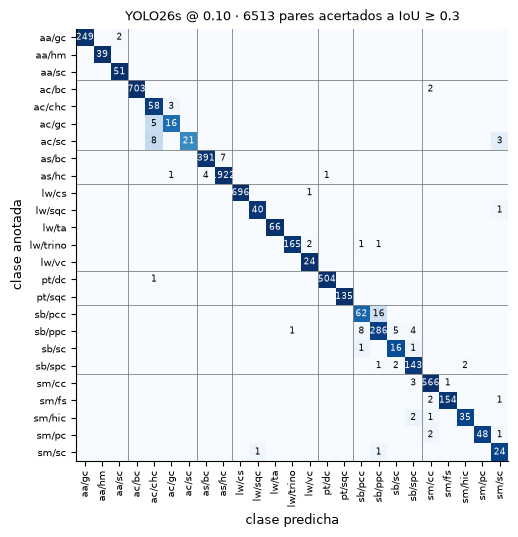

In [7]:
# Matriz de confusión del mejor modelo, entre los pares acertados sin exigir la clase.
best_run = max(RUNS, key=lambda run: by_model[run]["map_30"])
m = models[best_run]
threshold = m.thresholds[MIN_PRECISIONS[0]]
kept = m.test.select(torch.arange(m.matched.above(threshold)))
pairs = assignments(overlaps(kept, truth, class_aware=False), MATCH_IOU)
confusion = pd.crosstab(
    pd.Series([labels.name(int(truth.labels[t])) for _, t in pairs], name="anotada"),
    pd.Series([labels.name(int(kept.labels[p])) for p, _ in pairs], name="predicha"),
).reindex(index=labels.names, columns=labels.names, fill_value=0)
normalized = confusion.div(confusion.sum(axis=1).replace(0, 1), axis=0).to_numpy()

fig, ax = plt.subplots(figsize=(TEXT_WIDTH_IN, TEXT_WIDTH_IN * 0.92))
ax.grid(False)
ax.imshow(normalized, cmap="Blues", vmin=0, vmax=1)
for (i, j), value in np.ndenumerate(confusion.to_numpy()):
    if value:
        ax.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            fontsize=6.5,
            color="white" if normalized[i, j] > 0.6 else "black",
        )
ax.set_xticks(range(len(labels)), labels.names, rotation=90, fontsize=7.5)
ax.set_yticks(range(len(labels)), labels.names, fontsize=7.5)
ax.set(
    xlabel="clase predicha",
    ylabel="clase anotada",
    title=f"{RUNS[best_run]} @ {threshold:.2f} · {len(pairs)} pares acertados a IoU ≥ {MATCH_IOU}",
)
species_edges = [
    i
    for i in range(1, len(labels))
    if split_label(labels.names[i])[0] != split_label(labels.names[i - 1])[0]
]
for edge in species_edges:
    ax.axhline(edge - 0.5, color="gray", lw=0.6)
    ax.axvline(edge - 0.5, color="gray", lw=0.6)
reporte.save_figure(fig, OUT / "confusion")
off_diagonal = confusion.to_numpy().sum() - np.trace(confusion.to_numpy())
print(
    f"{RUNS[best_run]}: {off_diagonal} de {len(pairs)} pares con otra clase ({off_diagonal / len(pairs):.1%})"
)
plt.show()

In [8]:
# Carga de revisión: lo que cada modelo deja de más (falsos positivos) y de menos (cajas
# perdidas) al punto de operación, por tipo de error y por hora de audio equivalente.
sources = cache.sources(cache.TEST, reference.n_images)
test_hours = reference.n_images / WINDOWS_PER_HOUR
boxes_per_window = torch.bincount(truth.image_ids.long(), minlength=reference.n_images)
empty_windows = boxes_per_window == 0


def max_overlap(queries: Boxes, targets: Boxes) -> tuple[Tensor, Tensor]:
    # Para cada caja de `queries`, el mayor IoU con una caja de `targets` en su ventana y la
    # etiqueta de esa caja (-1 si la ventana no tiene ninguna).
    best_iou = torch.zeros(len(queries.boxes))
    best_label = torch.full((len(queries.boxes),), -1, dtype=torch.long)
    query_xyxy = box_convert(queries.boxes, "cxcywh", "xyxy")
    target_xyxy = box_convert(targets.boxes, "cxcywh", "xyxy")
    target_rows = rows_by_image(targets.image_ids)
    for image_id, rows in rows_by_image(queries.image_ids).items():
        columns = target_rows.get(image_id)
        if columns is None:
            continue
        values, indices = box_iou(query_xyxy[rows], target_xyxy[columns]).max(dim=1)
        best_iou[rows] = values
        best_label[rows] = targets.labels[columns][indices].long()
    return best_iou, best_label


class Load(NamedTuple):
    threshold: float
    n_above: int
    fp_background: int  # sin ninguna caja anotada debajo
    fp_other_class: int  # sobre una caja anotada de otra clase
    fp_duplicate: int  # sobre una caja anotada de la misma clase ya acertada
    missed_bare: int  # cajas anotadas sin ninguna detección encima
    missed_covered: int  # cajas anotadas con una detección encima que no cuenta
    fp_in_empty: int  # detecciones en ventanas vacías

    @property
    def n_fp(self) -> int:
        return self.fp_background + self.fp_other_class + self.fp_duplicate

    @property
    def n_missed(self) -> int:
        return self.missed_bare + self.missed_covered


def load_at(m: Evaluated, threshold: float) -> Load:
    n_above = m.matched.above(threshold)
    kept = m.test.select(torch.arange(n_above))
    found = m.matched.found[:n_above].bool()
    false_positives = kept.select(~found)
    fp_iou, fp_label = max_overlap(false_positives, truth)
    on_call = fp_iou >= MATCH_IOU
    same_class = on_call & (fp_label == false_positives.labels.long())
    gt_found = torch.zeros(len(truth.boxes), dtype=torch.bool)
    for _, gt_row in assignments(overlaps(kept, truth, class_aware=True), MATCH_IOU):
        gt_found[gt_row] = True
    assert int(gt_found.sum()) == int(found.sum())  # el emparejamiento es el del protocolo
    missed = truth.select(~gt_found)
    missed_iou, _ = max_overlap(missed, kept)
    covered = missed_iou >= MATCH_IOU
    return Load(
        threshold,
        n_above,
        int((~on_call).sum()),
        int((on_call & ~same_class).sum()),
        int(same_class.sum()),
        int((~covered).sum()),
        int(covered.sum()),
        int(empty_windows[kept.image_ids.long()].sum()),
    )


def per_hour(count: int) -> str:
    return number(count / test_hours)


load_rows = []
loads = {run: {p: load_at(m, m.thresholds[p]) for p in MIN_PRECISIONS} for run, m in models.items()}
for run, name in RUNS.items():
    for min_precision, load in loads[run].items():
        load_rows.append(
            (
                name,
                number(min_precision, 2),
                number(load.threshold, 2),
                per_hour(load.n_above),
                per_hour(load.n_fp),
                per_hour(load.fp_background),
                per_hour(load.fp_other_class),
                per_hour(load.fp_duplicate),
                per_hour(load.n_missed),
                per_hour(load.missed_bare),
                per_hour(load.missed_covered),
                number(1000 * load.fp_in_empty / int(empty_windows.sum())),
            )
        )
reporte.write_rows(OUT / "carga.tex", load_rows)
best_load = loads[best_run][MIN_PRECISIONS[0]]
main_loads = [loads[run][MIN_PRECISIONS[0]] for run in RUNS]
load_values = {
    "windows_per_hour": number(WINDOWS_PER_HOUR),
    "test_hours": number(test_hours, 1),
    "pct_empty_test": percent(float(empty_windows.float().mean())),
    "boxes_per_hour": per_hour(len(truth.boxes)),
    "best_detections_per_hour": per_hour(best_load.n_above),
    "best_fp_per_hour": per_hour(best_load.n_fp),
    "best_fp_background_share": percent(best_load.fp_background / best_load.n_fp, 0),
    "best_missed_per_hour": per_hour(best_load.n_missed),
    "best_missed_bare_share": percent(best_load.missed_bare / best_load.n_missed, 0),
    "best_fp_alt_per_hour": per_hour(loads[best_run][MIN_PRECISIONS[1]].n_fp),
    "best_missed_alt_per_hour": per_hour(loads[best_run][MIN_PRECISIONS[1]].n_missed),
    "logmel_duplicates_main": per_hour(loads["detr_t10_logmel_v2"][MIN_PRECISIONS[0]].fp_duplicate),
    "logmel_duplicates_alt": per_hour(loads["detr_t10_logmel_v2"][MIN_PRECISIONS[1]].fp_duplicate),
    "fp_per_hour_min": per_hour(min(main_loads, key=lambda load: load.n_fp).n_fp),
    "fp_per_hour_max": per_hour(max(main_loads, key=lambda load: load.n_fp).n_fp),
    "missed_per_hour_min": per_hour(min(main_loads, key=lambda load: load.n_missed).n_missed),
    "missed_per_hour_max": per_hour(max(main_loads, key=lambda load: load.n_missed).n_missed),
    "fp_empty_min": number(
        1000 * min(load.fp_in_empty for load in main_loads) / int(empty_windows.sum())
    ),
    "fp_empty_max": number(
        1000 * max(load.fp_in_empty for load in main_loads) / int(empty_windows.sum())
    ),
    "fp_empty_hour_min": number(
        WINDOWS_PER_HOUR * min(load.fp_in_empty for load in main_loads) / int(empty_windows.sum())
    ),
    "fp_empty_hour_max": number(
        WINDOWS_PER_HOUR * max(load.fp_in_empty for load in main_loads) / int(empty_windows.sum())
    ),
}
pd.DataFrame(
    load_rows,
    columns=[
        "modelo",
        "P mín.",
        "umbral",
        "det/h",
        "FP/h",
        "fondo",
        "otra clase",
        "duplicado",
        "perdidas/h",
        "sin caja",
        "con caja",
        "FP por 1000 vacías",
    ],
)

,modelo,P mín.,umbral,det/h,FP/h,fondo,otra clase,duplicado,perdidas/h,sin caja,con caja,FP por 1000 vacías
0,YOLO26s,"0,70","0,10","2\,921",888,840,41,6,469,444,25,359
1,YOLO26s,"0,50","0,01","4\,165","1\,964","1\,872",78,14,302,273,29,783
2,Faster R-CNN,"0,70","0,74","2\,704",810,780,27,3,609,584,26,357
3,Faster R-CNN,"0,50","0,34","4\,244","2\,099","2\,016",75,8,358,316,42,861
4,AST-DETR log-mel,"0,70","0,27","2\,819",819,789,27,3,502,475,27,379
5,AST-DETR log-mel,"0,50","0,12","4\,411","2\,199","2\,112",71,17,291,251,39,977
6,AST-DETR aves,"0,70","0,26","2\,881",844,807,33,3,466,435,31,380
7,AST-DETR aves,"0,50","0,11","4\,453","2\,241","2\,138",88,15,290,241,49,998
8,ResNet-50 DETR,"0,70","0,33","2\,775",810,787,22,1,537,516,21,394
9,ResNet-50 DETR,"0,50","0,17","4\,572","2\,327","2\,251",71,5,258,221,37,"1\,099"


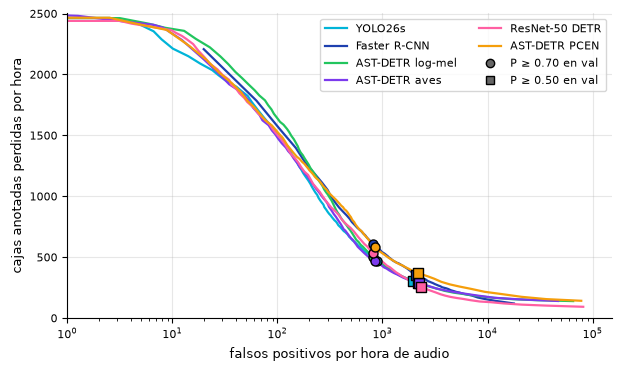

In [9]:
# Compromiso entre los dos errores a lo largo del umbral: falsos positivos frente a cajas
# perdidas, por hora de audio equivalente, con los dos puntos de operación marcados.
fig, ax = plt.subplots(figsize=(TEXT_WIDTH_IN, 3.6), constrained_layout=True)
for run, m in models.items():
    points = [operating_point(m.matched, t) for t in THRESHOLD_GRID]
    fp_hour = [(p.n_above - p.n_tp) / test_hours for p in points]
    missed_hour = [(m.matched.n_gt - p.n_tp) / test_hours for p in points]
    ax.plot(fp_hour, missed_hour, color=COLORS[run], lw=1.6, label=RUNS[run])
    for min_precision, load in loads[run].items():
        ax.scatter(
            load.n_fp / test_hours,
            load.n_missed / test_hours,
            marker=MARKERS[min_precision],
            color=COLORS[run],
            edgecolor="black",
            s=42,
            zorder=3,
        )
ax.set(
    xscale="log",
    xlabel="falsos positivos por hora de audio",
    ylabel="cajas anotadas perdidas por hora",
    ylim=(0, len(truth.boxes) / test_hours),
)
ax.set_xlim(left=1)
handles = [
    *ax.get_legend_handles_labels()[0],
    *(
        Line2D(
            [], [], ls="", marker=MARKERS[p], color="#666", mec="black", label=f"P ≥ {p:.2f} en val"
        )
        for p in MIN_PRECISIONS
    ),
]
ax.legend(handles=handles, loc="upper right", ncol=2)
reporte.save_figure(fig, OUT / "carga")
plt.show()

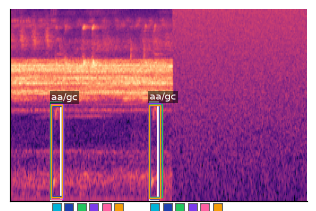

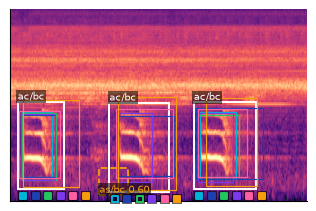

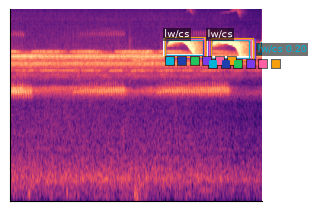

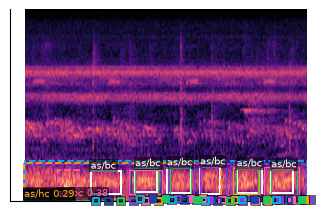

1397

In [10]:
# Las mismas ventanas de test para todos los modelos, cada uno en su punto de operación.
windows = torch.load(
    cache.split_path(cache.TEST), map_location="cpu", weights_only=False, mmap=True
)
db_low, db_high = cache.db_range()
paired_rows = {
    run: {gt: row for row, gt in assignments(overlaps(m.test, truth, class_aware=True), MATCH_IOU)}
    for run, m in models.items()
}
shown = {run: m.matched.above(m.thresholds[MIN_PRECISIONS[0]]) for run, m in models.items()}


def pick_windows(n: int) -> list[int]:
    boxes = pd.DataFrame(
        {"ventana": truth.image_ids.long().tolist(), "clase": truth.labels.long().tolist()}
    )
    boxes = boxes[boxes.clase.isin(detection)]
    boxes["grabación"] = [sources.recording_of_window[i] for i in boxes.ventana]
    candidates = (
        boxes.groupby("ventana")
        .first()
        .reset_index()
        .sample(frac=1.0, random_state=SEED)
        .drop_duplicates("grabación")
    )
    distinct = candidates.drop_duplicates("clase").ventana.tolist()
    rest = [w for w in candidates.ventana if w not in distinct]
    return (distinct + rest)[:n]


def rows_of(boxes: Boxes, image_id: int, limit: int | None = None) -> list[int]:
    ids = boxes.image_ids if limit is None else boxes.image_ids[:limit]
    return (ids == image_id).nonzero().flatten().tolist()


def found_by(run: str, gt_row: int) -> bool:
    return paired_rows[run].get(gt_row, len(models[run].test.boxes)) < shown[run]


def rectangle(
    ax: Axes, box: Tensor, color: str, style: str, width: float, text: str = "", top: bool = True
) -> tuple[float, float]:
    cx, cy, w, h = box.tolist()
    x0, y0 = (cx - w / 2) * P.clip_len_s, cy - h / 2
    ax.add_patch(Rectangle((x0, y0), w * P.clip_len_s, h, fill=False, ec=color, ls=style, lw=width))
    if text:
        ax.text(
            x0, y0 + h if top else y0, text, color=color, fontsize=7, va="bottom", bbox=CAPTION_BOX
        )
    return x0, y0


def hit_marks(ax: Axes, x0: float, y0: float, gt_row: int) -> None:
    for k, run in enumerate(RUNS):
        shift = ax.transData + ScaledTranslation(
            (4 + k * MARK_STEP_PT) / 72, -5 / 72, ax.figure.dpi_scale_trans
        )
        ax.scatter(
            [x0],
            [y0],
            s=46,
            marker="s",
            color="black",
            alpha=0.6,
            lw=0,
            transform=shift,
            clip_on=False,
            zorder=4,
        )
        ax.scatter(
            [x0],
            [y0],
            s=22,
            marker="s",
            facecolor=COLORS[run] if found_by(run, gt_row) else "none",
            edgecolor=COLORS[run],
            lw=1.4,
            transform=shift,
            clip_on=False,
            zorder=5,
        )


def draw_window(ax: Axes, image_id: int) -> None:
    ax.imshow(
        mel_to_unit(windows["images"][image_id][0], db_low, db_high),
        origin="lower",
        aspect="auto",
        cmap="magma",
        extent=(0, P.clip_len_s, 0, 1),
    )
    for gt_row in rows_of(truth, image_id):
        x0, y0 = rectangle(
            ax,
            truth.boxes[gt_row],
            ANNOTATION_COLOR,
            "-",
            1.4,
            labels.name(int(truth.labels[gt_row])),
        )
        hit_marks(ax, x0, y0, gt_row)
    for run, m in models.items():
        for row in rows_of(m.test, image_id, shown[run]):
            if m.matched.found[row]:
                rectangle(ax, m.test.boxes[row], COLORS[run], "-", 0.9)
            else:
                rectangle(
                    ax,
                    m.test.boxes[row],
                    COLORS[run],
                    "--",
                    1.3,
                    f"{labels.name(int(m.test.labels[row]))} {float(m.test.scores[row]):.2f}",
                    top=False,
                )
    ax.set(xticks=[], yticks=[])


def tally(run: str, chosen: list[int]) -> str:
    m = models[run]
    annotated = [gt_row for image_id in chosen for gt_row in rows_of(truth, image_id)]
    n_hits = sum(found_by(run, gt_row) for gt_row in annotated)
    false_positives = sum(
        int(m.matched.found[row] == 0)
        for image_id in chosen
        for row in rows_of(m.test, image_id, shown[run])
    )
    return f"{RUNS[run]} @ {number(m.thresholds[MIN_PRECISIONS[0]], 2)}: {n_hits}/{len(annotated)} acertadas, {false_positives} FP"


# Una imagen por ventana (media página de ancho) y el bloque de subfiguras que las coloca en
# dos columnas, con la leyenda de colores y el balance de cada modelo generados junto a ellas.
chosen = pick_windows(N_SHOWN)
subfigures: list[str] = []
for k, image_id in enumerate(chosen, start=1):
    fig, ax = plt.subplots(figsize=(TEXT_WIDTH_IN / 2, 2.0), constrained_layout=True)
    draw_window(ax, image_id)
    ax.grid(False)
    reporte.save_figure(fig, OUT / f"ventana_{k}")
    plt.show()
    recording = Path(sources.recordings[sources.recording_of_window[image_id]]).name.replace(
        "_", "\\_"
    )
    subfigures.append(
        "\\begin{subfigure}[t]{0.49\\textwidth}\n"
        f"    \\includegraphics[width=\\linewidth]{{figures/RE_2-3/ventana_{k}}}\n"
        f"    \\caption{{\\code{{{recording}}}, ventana {image_id}}}\n"
        "\\end{subfigure}"
    )
glue = [
    "\\\\[1.5ex]\n" if (i + 1) % COLUMNS == 0 else "\\hfill\n" for i in range(len(subfigures) - 1)
]
legend = " \\quad ".join(
    f"\\textcolor[HTML]{{{COLORS[run].lstrip('#').upper()}}}{{\\rule[0.4ex]{{1.6em}}{{2.4pt}}}} {tally(run, chosen)}"
    for run in RUNS
)
body = "".join(part for pair in zip(subfigures, [*glue, "\n"], strict=True) for part in pair)
(OUT / "ventanas.tex").write_text(
    "% generado por el cuaderno homónimo; no editar\n"
    + body
    + "\\par\\medskip{\\footnotesize "
    + legend
    + "}\n"
)

In [11]:
# Costo de inferencia por modelo: segundos de GPU y de CPU por hora de audio, sobre las mismas ventanas.
import time

from models.registry import load_checkpoint

# Ventanas cronometradas por dispositivo: en CPU los detectores de imagen tardan segundos por lote.
N_TIMED = {"cuda:1": 256, "cpu": 16}
if not torch.cuda.is_available():
    N_TIMED = {"cpu": N_TIMED["cpu"]}
cost_rows = []
for run, name in RUNS.items():
    loaded = load_checkpoint(RUNS_DIR / run / "best.pt", device="cpu")
    loaded.model.eval()
    seconds = {}
    for device, n_timed in N_TIMED.items():
        model = loaded.model.to(device)
        batch = 16 if device != "cpu" else 4
        timed = windows["images"][:n_timed]
        model.detect(timed[:batch].to(device), 0.5)  # calentamiento
        start = time.perf_counter()
        for i in range(0, n_timed, batch):
            model.detect(timed[i : i + batch].to(device), 0.5)
        if device != "cpu":
            torch.cuda.synchronize(device)
        seconds[device] = (time.perf_counter() - start) / (n_timed * P.clip_hop_s / 3600)
    cost_rows.append((name, *(number(seconds[d]) for d in N_TIMED)))
reporte.write_rows(OUT / "inferencia.tex", cost_rows)
pd.DataFrame(cost_rows, columns=["modelo", *(f"s por hora de audio ({d})" for d in N_TIMED)])

Overriding model.yaml nc=80 with nc=25


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/598 [00:00<?, ?it/s]

[transformers] DeformableDetrForObjectDetection LOAD REPORT from: /home/fcandia/tesis-primate/hf/SenseTime__deformable-detr-with-box-refine-two-stage
Key                                                    | Status   |                                                                                         
-------------------------------------------------------+----------+-----------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2, 3, 4, 5, 6}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([91]) vs model:torch.Size([25])          
model.decoder.class_embed.{0, 1, 2, 3, 4, 5, 6}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([91, 256]) vs model:torch.Size([25, 256])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

,modelo,s por hora de audio (cuda:1),s por hora de audio (cpu)
0,YOLO26s,27,851
1,Faster R-CNN,52,"4\,883"
2,AST-DETR log-mel,16,807
3,AST-DETR aves,16,"1\,243"
4,ResNet-50 DETR,73,"5\,716"
5,AST-DETR PCEN,16,"1\,474"


In [12]:
best_name = RUNS[best_run]
first = {run: paired(run, 0) for run in RUNS}
recall_ci = {run: first[run]["interval"]["recall"] for run in RUNS}
separated = [
    RUNS[run] for run in RUNS if run != best_run and recall_ci[run][1] < recall_ci[best_run][0]
]
overlapping = [
    RUNS[run] for run in RUNS if run != best_run and recall_ci[run][1] >= recall_ci[best_run][0]
]
top_recall_run = max(RUNS, key=lambda run: first[run]["test"]["recall"])
# mAP de los tres DETR antes de la supresión de no máximos, si la comparación anterior se guardó.
without_nms: dict[str, str] = {}
if WITHOUT_NMS.exists():
    previous = {m["model"]: m for m in json.loads(WITHOUT_NMS.read_text())["models"]}
    without_nms = {
        f"no_nms_{key}_map": number(previous[run]["map_30"], 3)
        for key, run in (
            ("logmel", "detr_t10_logmel_v2"),
            ("resnet", "detr_resnet"),
            ("pcen", "detr_t10_pcen_v2"),
        )
        if run in previous
    }
reporte.write_macros(
    OUT / "valores.tex",
    {
        "n_test_windows": number(reference.n_images),
        "n_test_boxes": number(len(truth.boxes)),
        "n_test_recordings": number(len(reference.recording_names)),
        "n_val_windows": number(report["val"]["windows"]),
        "n_detection_classes": number(len(detection)),
        "best_model": best_name,
        "best_map": number(by_model[best_run]["map_30"], 3),
        "best_threshold": number(first[best_run]["threshold"], 2),
        "best_recall": number(first[best_run]["test"]["recall"], 3),
        "best_recall_low": number(recall_ci[best_run][0], 3),
        "best_recall_high": number(recall_ci[best_run][1], 3),
        "best_precision": number(first[best_run]["test"]["precision"], 3),
        "separated": ", ".join(separated) or "ninguno",
        "overlapping": ", ".join(overlapping) or "ninguno",
        "logmel_recall": number(first["detr_t10_logmel_v2"]["test"]["recall"], 3),
        "pcen_recall": number(first["detr_t10_pcen_v2"]["test"]["recall"], 3),
        "logmel_map": number(by_model["detr_t10_logmel_v2"]["map_30"], 3),
        "pcen_map": number(by_model["detr_t10_pcen_v2"]["map_30"], 3),
        "resnet_map": number(by_model["detr_resnet"]["map_30"], 3),
        "frcnn_map": number(by_model["frcnn_v2"]["map_30"], 3),
        "frcnn_threshold": number(first["frcnn_v2"]["threshold"], 2),
        "yolo_threshold": number(first["yolo26s_v2"]["threshold"], 2),
        "logmel_threshold": number(first["detr_t10_logmel_v2"]["threshold"], 2),
        "birds_map": number(by_model["detr_t10_logmel_birds"]["map_30"], 3),
        "birds_recall": number(first["detr_t10_logmel_birds"]["test"]["recall"], 3),
        "birds_recall_low": number(recall_ci["detr_t10_logmel_birds"][0], 3),
        "birds_recall_high": number(recall_ci["detr_t10_logmel_birds"][1], 3),
        "birds_threshold": number(first["detr_t10_logmel_birds"]["threshold"], 2),
        "top_recall_model": RUNS[top_recall_run],
        "top_recall": number(first[top_recall_run]["test"]["recall"], 3),
        "top_recall_map": number(by_model[top_recall_run]["map_30"], 3),
        **without_nms,
        "n_pairs_best": number(len(pairs)),
        "pct_off_diagonal": percent(off_diagonal / len(pairs)),
        "n_shown": number(len(chosen)),
        **load_values,
    },
)
sorted(OUT.iterdir())

[PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-3/carga.png'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-3/carga.tex'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-3/confusion.png'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-3/curvas_pr.png'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-3/ejes.tex'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-3/inferencia.tex'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-3/por_clase.tex'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-3/resumen.tex'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-3/valores.tex'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-3/ventana.tex'),
 PosixPath('/home/fcandia/tesis-primate/research/reportes/figures/RE_2-3/ventana_1.png'),
 PosixPath('/home/fcandia/te